##### **Шаг 1**. Для начала работы подгружаю все необходимые для выполнения задания библиотеки

In [1]:
import re  # Для работы с регулярными выражениями
import nltk  # Для работы с текстом
from nltk.corpus import stopwords  # Для удаления стоп-слов
nltk.download('stopwords') 
from collections import Counter  # Для подсчета частоты элемементов
import matplotlib.pyplot as plt  # Для визуализации
from pymorphy3 import MorphAnalyzer  

import requests

[nltk_data] Downloading package stopwords to /Users/polya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---

##### **Шаг 2**. Загрузка текста для анализа

Для дополнительной тренировки я решила использовать следующий подход: загрузка текста → добавление его в репозиторий на GitHub → работа с этим текстом в тетради.

Вероятно, можно было бы просто скопировать для работы первые две главы «Мцыри», но такой вариант показался мне менее интересным :) 

К слову, изначально я планировала сделать репозиторий приватным, но тогда возникала ошибка с ссылкой на файл (если я правильно понимаю, она каждый раз была временной), так что пришлось делать его публичным. 

In [2]:
url = "https://raw.githubusercontent.com/polina03avdeevaa/homework_python_1/refs/heads/main/Mcyri.txt"

response = requests.get(url)
text = response.text
print(text)  # Проверка: сохранился текст или нет

 1

 Немного лет тому назад,
 Там, где, сливаяся, шумят,
 Обнявшись, будто две сестры,
 Струи Арагвы и Куры,
 Был монастырь. Из-за горы
 И нынче видит пешеход
 Столбы обрушенных ворот,
 И башни, и церковный свод;
 Но не курится уж под ним
 Кадильниц благовонный дым,
 Не слышно пенье в поздний час
 Молящих иноков за нас.
 Теперь один старик седой,
 Развалин страж полуживой,
 Людьми и смертию забыт,
 Сметает пыль с могильных плит,
 Которых надпись говорит
 О славе прошлой – и о том,
 Как, удручен своим венцом,
 Такой-то царь, в такой-то год,
 Вручал России свой народ.


* * *

 И божья благодать сошла
 На Грузию! Она цвела
 С тех пор в тени своих садов,
 Не опасаяся врагов,
 3а гранью дружеских штыков.

 2

 Однажды русский генерал
 Из гор к Тифлису проезжал;
 Ребенка пленного он вез.
 Тот занемог, не перенес
 Трудов далекого пути;
 Он был, казалось, лет шести,
 Как серна гор, пуглив и дик
 И слаб и гибок, как тростник.
 Но в нем мучительный недуг
 Развил тогда могучий дух
 Его отцов. Бе

---

#### **Шаг 3**. Регулярные выражения

*Задание 1. Напишите регулярное выражение, которое найдет все слова, начинающиеся с «ста»:*

In [3]:
search_result_1 = re.findall(r'\bста\w*', text)
print(f"Слова, начинающиеся на «ста»: {search_result_1}")

Слова, начинающиеся на «ста»: ['старик', 'стал', 'старик', 'старик', 'стало', 'стариков', 'старости', 'стало', 'стал', 'стал', 'стал', 'стал', 'стал', 'старик', 'стал', 'стал', 'стало', 'стада', 'стану', 'стану']


Этот вариант работает, однако из-за чувствительности регистра может выводить не все слова. Мне захотелось это исправить, не прибегая на данном этапе к использованию `text.lower()`. Захотелось чего-то новенького :)

В статье на [Хабр](https://habr.com/ru/articles/956068/) я нашла информацию о флагах комплияции, среди которых есть аргумент `re.IGNORECASE`, позволяющий выполнять поиск без учета регистра. 

Добавляю его, чтобы получить более полный список слов: 

In [4]:
search_result_full_1 = re.findall(r'\bста\w*', text, flags = re.IGNORECASE)
print(f"Слова, начинающиеся на «ста»: {search_result_full_1}")

Слова, начинающиеся на «ста»: ['старик', 'Стал', 'стал', 'Старик', 'старик', 'старик', 'стало', 'стариков', 'старости', 'стало', 'стал', 'стал', 'стал', 'стал', 'стал', 'старик', 'стал', 'стал', 'стало', 'стада', 'стану', 'стану']


И действительно, помимо слов, начинающихся со строчной буквы, появились и слова с заглавной. Аргумент работает корректно и позволяет устранить образовавшиеся пропуски. 

*Задание 2. Расширьте: найдите слова с «ста» внутри (не только в начале).*

In [5]:
# Вариант с флагом
search_result_2 = re.findall(r'\b\w*ста\w*\b', text, flags = re.IGNORECASE)  # Немного изменяем шаблон, чтобы не было границ слов
print(f"Слова, содержащие в себе «ста»: {search_result_2}")

Слова, содержащие в себе «ста»: ['старик', 'остался', 'Стал', 'стал', 'Привстал', 'остаток', 'Старик', 'старик', 'расстаться', 'старик', 'стало', 'стариков', 'старости', 'устав', 'стало', 'стал', 'кустам', 'стал', 'стал', 'Простая', 'настает', 'стал', 'куста', 'стал', 'старик', 'Встал', 'стал', 'остаток', 'стал', 'стало', 'Оставила', 'усталую', 'кустах', 'встать', 'хрусталь', 'стада', 'Останься', 'усталый', 'остальное', 'стану', 'куста', 'густа', 'стану']


In [6]:
# На всякий случай добавлю код без флага
search_result_2_without_flag = re.findall(r'\b\w*ста\w*\b', text) 
print(f"Слова, содержащие в себе «ста»: {search_result_2_without_flag}")


Слова, содержащие в себе «ста»: ['старик', 'остался', 'стал', 'Привстал', 'остаток', 'старик', 'расстаться', 'старик', 'стало', 'стариков', 'старости', 'устав', 'стало', 'стал', 'кустам', 'стал', 'стал', 'Простая', 'настает', 'стал', 'куста', 'стал', 'старик', 'Встал', 'стал', 'остаток', 'стал', 'стало', 'Оставила', 'усталую', 'кустах', 'встать', 'хрусталь', 'стада', 'Останься', 'усталый', 'остальное', 'стану', 'куста', 'густа', 'стану']


Так как теперь я знакома с флагами, решила продолжить использовать использовать их :)

Для эксперимента я попробовала заменить `'\b\w*ста\w*\b'` на `'\b\w+ста\w*\b'`. Однако я поняла, что результат такого кода не полностью соответсвует условию: нужны не только слова, содержащие «ста» внутри, но еще и слова, начинающиеся с «ста». Следовательно, правильнее оставить `*`.

*Задание 3. Модернизируйте: сделайте «т» опциональной (замените на любой символ: [а-я]?).*

In [7]:
search_result_3 = re.findall(r'\b\w*с[а-я]?а\w*\b', text, flags = re.IGNORECASE) 
print(f"Слова с опциональной «т»: {search_result_3}")

Слова с опциональной «т»: ['старик', 'славе', 'садов', 'опасаяся', 'слаб', 'слабый', 'остался', 'спасен', 'Сначала', 'Стал', 'слаб', 'стал', 'Привстал', 'остаток', 'рассказать', 'скалы', 'Старик', 'спас', 'сказать', 'старик', 'сладостных', 'расстаться', 'Пускай', 'слаб', 'старик', 'скал', 'стало', 'стариков', 'сладостных', 'касалися', 'Рассказы', 'старости', 'прекрасна', 'Скажи', 'устав', 'сжал', 'сам', 'стало', 'скал', 'сад', 'стал', 'голосам', 'кустам', 'голоса', 'рассказать', 'стал', 'Спускаться', 'стал', 'сладко', 'Простая', 'настает', 'скале', 'сакли', 'пускай', 'сладкою', 'плескал', 'сакле', 'небесах', 'стал', 'куста', 'стал', 'старик', 'слабый', 'Встал', 'скачок', 'сам', 'стал', 'Сдавил', 'остаток', 'стал', 'ласкал', 'стало', 'скал', 'Оставила', 'распускал', 'сад', 'сладость', 'усталую', 'Сама', 'скал', 'спал', 'кустах', 'небесах', 'встать', 'сладко', 'хрусталь', 'сладостней', 'стада', 'ласкалась', 'Останься', 'усталый', 'остальное', 'сам', 'пускай', 'скал', 'стану', 'сад', 'кус

Меня немного смущает наличие таких слов как «садов», «опасаяся», «касалися», «сам», «сад», «голосам», «голоса», «сакли», «сакле», «небесах», «сама» и «вполголоса». Тем не менее, насколько я понимаю, они соответствуют условиям задания, так как после «с» может следовать любая буква.  

При этом слова с буквой «т» в «ста» продолжают встречаться, так как в диапазоне [а-я] эта буква по-прежнему учитывается.

---

#### **Шаг 4.** Нормализация текста

*Задание 1. Приведите текст к нижнему регистру.*

*Задание 2. Удалите пунктуацию и \n с помощью regex (используйте re.sub(r'[^а-яё\s]', ' ', text.lower()) как основу).*

In [8]:
normalized_text = re.sub(r'[^а-яё\s]', ' ', text.lower())
print(normalized_text)

  

 немного лет тому назад 
 там  где  сливаяся  шумят 
 обнявшись  будто две сестры 
 струи арагвы и куры 
 был монастырь  из за горы
 и нынче видит пешеход
 столбы обрушенных ворот 
 и башни  и церковный свод 
 но не курится уж под ним
 кадильниц благовонный дым 
 не слышно пенье в поздний час
 молящих иноков за нас 
 теперь один старик седой 
 развалин страж полуживой 
 людьми и смертию забыт 
 сметает пыль с могильных плит 
 которых надпись говорит
 о славе прошлой   и о том 
 как  удручен своим венцом 
 такой то царь  в такой то год 
 вручал россии свой народ 


     

 и божья благодать сошла
 на грузию  она цвела
 с тех пор в тени своих садов 
 не опасаяся врагов 
  а гранью дружеских штыков 

  

 однажды русский генерал
 из гор к тифлису проезжал 
 ребенка пленного он вез 
 тот занемог  не перенес
 трудов далекого пути 
 он был  казалось  лет шести 
 как серна гор  пуглив и дик
 и слаб и гибок  как тростник 
 но в нем мучительный недуг
 развил тогда могучий дух
 его отцов  бе

Я не прописываю отдельно удаление `\n`, так как в регулярном выражении `\s`  учитывает все пробельные символы, в том числе перевод строки (а также пробелы и табуляции). 

---

#### **Шаг 5.** Токенизация

*Задание 1. Токенизируйте `normalized_text` на слова (используйте `re.findall(r'\w+', normalized_text)`). Подсчитайте общее число токенов и уникальных (используйте `set` или `Counter`)*

Для начала получу токены. Хочется убедиться, что все правильно. 

In [9]:
token_text = re.findall(r'\w+', normalized_text)  # Токенизация 
print(token_text)

['немного', 'лет', 'тому', 'назад', 'там', 'где', 'сливаяся', 'шумят', 'обнявшись', 'будто', 'две', 'сестры', 'струи', 'арагвы', 'и', 'куры', 'был', 'монастырь', 'из', 'за', 'горы', 'и', 'нынче', 'видит', 'пешеход', 'столбы', 'обрушенных', 'ворот', 'и', 'башни', 'и', 'церковный', 'свод', 'но', 'не', 'курится', 'уж', 'под', 'ним', 'кадильниц', 'благовонный', 'дым', 'не', 'слышно', 'пенье', 'в', 'поздний', 'час', 'молящих', 'иноков', 'за', 'нас', 'теперь', 'один', 'старик', 'седой', 'развалин', 'страж', 'полуживой', 'людьми', 'и', 'смертию', 'забыт', 'сметает', 'пыль', 'с', 'могильных', 'плит', 'которых', 'надпись', 'говорит', 'о', 'славе', 'прошлой', 'и', 'о', 'том', 'как', 'удручен', 'своим', 'венцом', 'такой', 'то', 'царь', 'в', 'такой', 'то', 'год', 'вручал', 'россии', 'свой', 'народ', 'и', 'божья', 'благодать', 'сошла', 'на', 'грузию', 'она', 'цвела', 'с', 'тех', 'пор', 'в', 'тени', 'своих', 'садов', 'не', 'опасаяся', 'врагов', 'а', 'гранью', 'дружеских', 'штыков', 'однажды', 'русск

Кажется, результат удовлетворительный. Теперь с помощью `set()` подсчитаю общее число токенов, а также найду количество уникальных токенов. 

In [10]:
tokens_count = len(token_text)
print(f"Общее число токенов: {tokens_count}")

Общее число токенов: 3353


In [11]:
unique_tokens = len(set(token_text))
print(f"Количество уникальных токенов: {unique_tokens}")

Количество уникальных токенов: 1663


Итак, общее число токенов равно 3353, а количество уникальных токенов — 1663. Практически половина от общего числа является уникальной. 

Дополнительно хочется "поиграться" с `Counter`. 

In [12]:
сounts = Counter(token_text)
print(сounts.most_common(5))  # Посмотрим самые популярные элементы (топ-5) 

[('и', 201), ('я', 109), ('в', 91), ('как', 45), ('не', 43)]


Топ-5 самых популярных слов получился... не самым репрезентативным... Это связано с тем, что ранее не удалялись стоп-слова. 

Тем не менее, для эксперимента можно немного забежать вперед: удалить их и посмотреть, что получится. 

In [13]:
stopwords_ru = stopwords.words('russian')
tokens_no_stop = [token for token in token_text if token not in stopwords_ru]

counts_without_stop_words = Counter(tokens_no_stop)

print(counts_without_stop_words.most_common(5))

[('лишь', 12), ('мог', 11), ('грудь', 10), ('мной', 10), ('меж', 10)]


Здесь уже более интересные слова, хотя все равно далеко от идеала :)

*Задание 2. Токенизируйте оригинальный text на строки (split('\n')). Сколько строк?*

In [14]:
print(f"Общее количество строк в оригинальном тексте: {len(text.split('\n'))}")

Общее количество строк в оригинальном тексте: 837


*Задание 3. Напишите цикл: сохраните слова с заглавной буквы (из оригинального текста).*

In [15]:
lines = text.split('\n')  # Получаю стоки из  текста
text_capital_words = [] 

for line in lines:
    words = line.split()
    for word in words:
        if word[0].isupper():
            text_capital_words.append(word)

print(f"Слова с заглавной буквы: {text_capital_words}")

Слова с заглавной буквы: ['Немного', 'Там,', 'Обнявшись,', 'Струи', 'Арагвы', 'Куры,', 'Был', 'Из-за', 'И', 'Столбы', 'И', 'Но', 'Кадильниц', 'Не', 'Молящих', 'Теперь', 'Развалин', 'Людьми', 'Сметает', 'Которых', 'О', 'Как,', 'Такой-то', 'Вручал', 'России', 'И', 'На', 'Грузию!', 'Она', 'С', 'Не', 'Однажды', 'Из', 'Тифлису', 'Ребенка', 'Тот', 'Трудов', 'Он', 'Как', 'И', 'Но', 'Развил', 'Его', 'Без', 'Томился,', 'Из', 'Он', 'И', 'Из', 'Больного', 'Хранительных', 'Искусством', 'Но,', 'Сначала', 'Бродил', 'Смотрел,', 'Гоним', 'По', 'Но', 'Стал', 'Был', 'И,', 'Уже', 'Изречь', 'Как', 'Осенней', 'Темный', 'Тянулся', 'Три', 'Напрасны', 'Его', 'И', 'Он', 'И', 'Болезнь', 'Он', 'И', 'И', 'Тогда', 'С', 'И,', 'Привстал,', 'И', 'Сюда', 'Все', 'Словами', 'Но', 'И', 'Немного', 'А', 'Я', 'Таких', 'Но', 'Я', 'Я', 'Одну', 'Она,', 'Изгрызла', 'Она', 'От', 'В', 'Где', 'Где', 'Я', 'Вскормил', 'Ее', 'Я', 'И', 'Старик!', 'Что', 'Зачем?..', 'Угрюм', 'Грозой', 'Я', 'Душой', 'Я', 'Священных', 'Конечно,', 'Чтоб',

В данном случае выводятся ВСЕ слова с заглавной буквы. 

*Задание 4. Модернизируйте цикл: исключите первые слова строк (используйте line.split() и проверку позиции).*

In [16]:
lines = text.split('\n')  # Получаю стоки из  текста
text_capital_words_new = [] 

for line in lines:
    words = line.split()
    for word in words[1:]: 
        if word[0].isupper():
            text_capital_words_new.append(word)

print(f"Слова с заглавной буквы: {text_capital_words_new}")

Слова с заглавной буквы: ['Арагвы', 'Куры,', 'Из-за', 'России', 'Грузию!', 'Она', 'Тифлису', 'Без', 'Темный', 'Угрюм', 'И', 'Знал', 'Ты', 'Пышные', 'Кавказ;', 'Жил', 'О,', 'Много', 'Бледный', 'Хотя', 'Из-под', 'Порой', 'Летние', 'Помню', 'Отрадный', 'Уж', 'Я', 'Я', 'Лишь', 'Вдруг', 'Сырую', 'И', 'Но', 'Он', 'И', 'Туманный', 'Вдали', 'Смутный', 'Чтоб', 'Напрасно', 'Таков', 'И', 'Со', 'Едва', 'Мир', 'Лишь', 'Сквозь', 'Арагва', 'Кура,', 'Меня', 'Чешуей', 'Она', 'Божий', 'Безумный', 'Верь', 'Кавказ!']


Данный код даёт не совсем «чистый» результат: помимо имён и заголовков часто попадаются (и довольно часто) обычные слова.

Чаще всего это связано с тем, что строчка разбивается на два предложения и, соотвтетственно, второе предложение начинается с заглавной буквы. Например: «Был монастырь. *Из-за* горы» или «На Грузию! *Она* цвела!» или «Его отцов. *Без* жалоб он» или «Осенней ночью. Темный лес» и так далее. 

Из-за этого результат не полностью соответствует ожидаемому.

Однако можно расширить код, чтобы слова в начале предложений тоже не засчитывались. 

In [17]:
lines = text.split('\n')
text_capital_words_result = []

for line in lines:
    sentences = re.split(r'[.?!]\s*', line) # Вот здесь как раз делим текст на предложения внутри строки
    for sentence in sentences:
        words = sentence.split()
        for word in words[1:]: 
            if word and word[0].isupper():
                text_capital_words_result.append(word)

print(text_capital_words_result)


['Арагвы', 'Куры,', 'России', 'Грузию', 'Тифлису', 'Знал', 'Пышные', 'Кавказ;', 'Я', 'Он', 'Таков', 'Лишь', 'Арагва', 'Кура,', 'Кавказ']


В таком случае результат получается сильно чище! 

Единственное, все равно попадаются слова вроде «Я», «Он», «Таков» и «Лишь», но подобных единиц стало в разы меньше. 

In [18]:
# Вывод

# Задание №1
print(f"Общее число токенов: {tokens_count}")
print(f"Количество уникальных токенов: {unique_tokens}")

print(f"Топ-5 популярных слов после очистки от стоп-слов: {counts_without_stop_words.most_common(5)}")


# Задание №2
print(f"Общее количество строк в оригинальном тексте: {len(text.split('\n'))}")

# Задание №3
print(f"Слова с заглавной буквы: {text_capital_words}")
print(f"Список имен и заголовков: {text_capital_words_result}")

Общее число токенов: 3353
Количество уникальных токенов: 1663
Топ-5 популярных слов после очистки от стоп-слов: [('лишь', 12), ('мог', 11), ('грудь', 10), ('мной', 10), ('меж', 10)]
Общее количество строк в оригинальном тексте: 837
Слова с заглавной буквы: ['Немного', 'Там,', 'Обнявшись,', 'Струи', 'Арагвы', 'Куры,', 'Был', 'Из-за', 'И', 'Столбы', 'И', 'Но', 'Кадильниц', 'Не', 'Молящих', 'Теперь', 'Развалин', 'Людьми', 'Сметает', 'Которых', 'О', 'Как,', 'Такой-то', 'Вручал', 'России', 'И', 'На', 'Грузию!', 'Она', 'С', 'Не', 'Однажды', 'Из', 'Тифлису', 'Ребенка', 'Тот', 'Трудов', 'Он', 'Как', 'И', 'Но', 'Развил', 'Его', 'Без', 'Томился,', 'Из', 'Он', 'И', 'Из', 'Больного', 'Хранительных', 'Искусством', 'Но,', 'Сначала', 'Бродил', 'Смотрел,', 'Гоним', 'По', 'Но', 'Стал', 'Был', 'И,', 'Уже', 'Изречь', 'Как', 'Осенней', 'Темный', 'Тянулся', 'Три', 'Напрасны', 'Его', 'И', 'Он', 'И', 'Болезнь', 'Он', 'И', 'И', 'Тогда', 'С', 'И,', 'Привстал,', 'И', 'Сюда', 'Все', 'Словами', 'Но', 'И', 'Немног

---

#### **Шаг 6.** Удаление стоп-слов

*Задание 1. Импортируйте стоп-слова NLTK для русского.* 

In [19]:
from nltk.corpus import stopwords  # Для удаления стоп-слов
nltk.download('stopwords') 

stopwords_ru = stopwords.words('russian')

[nltk_data] Downloading package stopwords to /Users/polya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


*Задание 2. Создайте список токенов без стоп-слов (цикл или list comprehension).* 

In [20]:
tokens_no_stop_new = [token for token in token_text if token.lower() not in stopwords_ru]

*Задание 3. Подсчитайте оставшиеся токены и уникальные.*

In [21]:
tokens_count_no_stop = len(tokens_no_stop_new)
print(f"Общее число оставшихся токенов: {tokens_count_no_stop}")

unique_tokens_no_stop = len(set(tokens_no_stop_new))
print(f"Количество оставшихся уникальных токенов: {unique_tokens_no_stop}")

Общее число оставшихся токенов: 2139
Количество оставшихся уникальных токенов: 1539


_Задание 4. Добавьте к стоп-словам слова с 'бол' (опциональная 'о': regex r'\w*б[о]?л\w*'). Удалите их. Сколько осталось?_

In [22]:
pattern = r'\w*б[о]?л\w*'
new_stop_words = [token.lower() for token in tokens_no_stop_new if re.fullmatch(pattern, token)]

stopwords_ru_new = stopwords_ru + new_stop_words
filtered_tokens = [token for token in token_text if token.lower() not in stopwords_ru_new if len(token) > 1]

# Проверяю
print(f"Общее число токенов после удаления «бол»: {len(filtered_tokens)}")
print(f"Количество уникальных токенов после удаления «бол»: {len(set(filtered_tokens))}")

Общее число токенов после удаления «бол»: 2101
Количество уникальных токенов после удаления «бол»: 1514


Итак, после удаления слов с «бол» (опциональной «о») общее число токенов снизилось с 2139 до 2109, а количество уникальных токенов — с 1539 до 1515. 

Изменения не очень значительные, но они есть. 

---

#### **Шаг 7.** Частотный анализ

*Задание 1. Используйте Counter на filtered_tokens: выведите топ-10 самых частых слов.*

In [23]:
freq = Counter(filtered_tokens)
print(freq.most_common(10))

[('лишь', 12), ('мог', 11), ('грудь', 10), ('мной', 10), ('меж', 10), ('стал', 9), ('долго', 8), ('мою', 8), ('жил', 8), ('моей', 8)]


*Задание 2. Визуализируйте: Постройте барчарт топ-10 (matplotlib: plt.bar()). Подпишите оси ('Слова', 'Частота').*

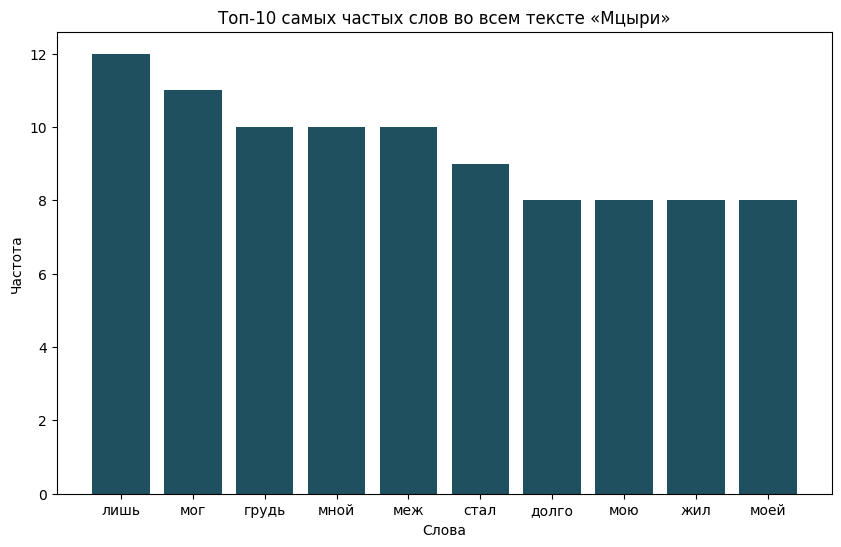

In [24]:
top_10 = freq.most_common(10)
words, counts = zip(*top_10)  # Распаковка кортежа, чтобы получить данные для графика 

plt.figure(figsize=(10,6))
plt.bar(words, counts, color = "#1E505F")
plt.xlabel('Слова')
plt.ylabel('Частота')
plt.title('Топ-10 самых частых слов во всем тексте «Мцыри»')
plt.show()

*Задание 3. Гуманитарная интерпретация: Разделите текст на две главы (используйте индекс поиска 'Глава 2' или вручную). Сравните топ-5 частых слов в каждой (Counter для каждой главы). Что это говорит о темах? (Например, в первой — 'монастырь/плен', во второй — 'свобода/бег').*

In [25]:
url = "https://raw.githubusercontent.com/polina03avdeevaa/homework_python_1/refs/heads/main/Mcyri.txt"
response = requests.get(url)
text = response.text
corpus = re.split(r'^\s*\d+\s*$', text, flags=re.MULTILINE)
print(len(corpus))  

27


Разделить текст на главы получилось корректно. В данном файле они разбиваются не по тексту «Глава...», как было в работе на семинаре, а просто с помощью арабских цифр. 

В результате получается 27 глав, а в «Мцыри» их 26: это может быть из-за наличия «нулевой» главы. 

Предобработаю текст для дальнейшего анализа (как мы делали с «Евгением Онегиным»): 

In [26]:
from pymorphy3 import MorphAnalyzer 
morph = MorphAnalyzer()

clean_texts = []
for text in corpus:
    text = re.sub(r'\n', ' ', text)
    text = re.sub('[^а-яА-ЯёЁ -]', '', text.lower())
    tokens = re.findall(r'\w+', text)  # Токенизация 
    lemmatized_text = [morph.parse(tok)[0].normal_form for tok in tokens]
    text_no_stop = [token for token in lemmatized_text if token.lower() not in stopwords_ru]
    text_no_stop = ' '.join(text_no_stop)
    clean_texts.append(text_no_stop)

print(clean_texts)


['', 'немного год назад сливаясь шуметь обняться сестра струить арагва кура монастырь гора нынче видеть пешеход столб обрушить ворота башня церковный свод куриться кадильница благовонный дым слышный пение поздний час молить инок старик седой развалины страж полуживой человек смертие забытый сметать пыль могильный плита который надпись говорить слава прошлый удручённый свой венец царь год вручать россия свой народ божий благодать сойти грузия цвести пора тень свой сад опасаясь враг грань дружеский штык', 'однажды русский генерал гора тифлис проезжать ребёнок пленный везти занемочь перенести труд далёкий путь казаться год шесть серный гора пугливый дик слабый гибкий тростник немой мучительный недуг развить могучий дух отец жалоба томиться слабый стон детский губа вылетать знак пища отвергать тихо гордо умирать жалость монах больной призреть стена хранительный остаться искусство дружеский спасти чуждый ребяческий утеха сначала бегать весь бродить безмолвный одинокий смотреть вздыхать вост

Получу данные по первой главе: 

In [27]:
tokens_chapter1 = clean_texts[1].split()
print(f"Список слов в первой главе: {tokens_chapter1}") 

counter_chapter1 = Counter(tokens_chapter1)
top5_chapter1 = counter_chapter1.most_common(5)
print(f"Топ-5 слов в главе №1: {top5_chapter1}")

words1, counts1 = zip(*top5_chapter1)

Список слов в первой главе: ['немного', 'год', 'назад', 'сливаясь', 'шуметь', 'обняться', 'сестра', 'струить', 'арагва', 'кура', 'монастырь', 'гора', 'нынче', 'видеть', 'пешеход', 'столб', 'обрушить', 'ворота', 'башня', 'церковный', 'свод', 'куриться', 'кадильница', 'благовонный', 'дым', 'слышный', 'пение', 'поздний', 'час', 'молить', 'инок', 'старик', 'седой', 'развалины', 'страж', 'полуживой', 'человек', 'смертие', 'забытый', 'сметать', 'пыль', 'могильный', 'плита', 'который', 'надпись', 'говорить', 'слава', 'прошлый', 'удручённый', 'свой', 'венец', 'царь', 'год', 'вручать', 'россия', 'свой', 'народ', 'божий', 'благодать', 'сойти', 'грузия', 'цвести', 'пора', 'тень', 'свой', 'сад', 'опасаясь', 'враг', 'грань', 'дружеский', 'штык']
Топ-5 слов в главе №1: [('свой', 3), ('год', 2), ('немного', 1), ('назад', 1), ('сливаясь', 1)]


Теперь по второй: 

In [28]:
tokens_chapter2 = clean_texts[2].split()
print(f"Список слов в первой главе: {tokens_chapter2}") 

counter_chapter2 = Counter(tokens_chapter2)
top5_chapter2 = counter_chapter2.most_common(5)
print(f"Топ-5 слов в главе №2: {top5_chapter2}")

words2, counts2 = zip(*top5_chapter2)

Список слов в первой главе: ['однажды', 'русский', 'генерал', 'гора', 'тифлис', 'проезжать', 'ребёнок', 'пленный', 'везти', 'занемочь', 'перенести', 'труд', 'далёкий', 'путь', 'казаться', 'год', 'шесть', 'серный', 'гора', 'пугливый', 'дик', 'слабый', 'гибкий', 'тростник', 'немой', 'мучительный', 'недуг', 'развить', 'могучий', 'дух', 'отец', 'жалоба', 'томиться', 'слабый', 'стон', 'детский', 'губа', 'вылетать', 'знак', 'пища', 'отвергать', 'тихо', 'гордо', 'умирать', 'жалость', 'монах', 'больной', 'призреть', 'стена', 'хранительный', 'остаться', 'искусство', 'дружеский', 'спасти', 'чуждый', 'ребяческий', 'утеха', 'сначала', 'бегать', 'весь', 'бродить', 'безмолвный', 'одинокий', 'смотреть', 'вздыхать', 'восток', 'гонимый', 'неясный', 'тоска', 'сторона', 'свой', 'родный', 'плен', 'привыкнуть', 'стать', 'понимать', 'чужой', 'язык', 'окрестить', 'святой', 'отец', 'шумный', 'свет', 'незнакомый', 'хотеть', 'цвет', 'год', 'изречь', 'монашеский', 'обет', 'однажды', 'исчезнуть', 'осенний', 'ночь

Мне показались такие слова не самыми репрезентативными. Для более полноценного анализа я решила расширить выборку и взять первые пять глав.

In [29]:
tokens_chapter3 = clean_texts[3].split()
print(f"Список слов в первой главе: {tokens_chapter3}") 

counter_chapter3 = Counter(tokens_chapter3)
top5_chapter3 = counter_chapter3.most_common(5)
print(f"Топ-5 слов в главе №3: {top5_chapter3}")

words3, counts3 = zip(*top5_chapter3)

Список слов в первой главе: ['слушать', 'исповедь', 'сюда', 'прийти', 'благодарить', 'всё', 'хороший', 'нибыть', 'слово', 'облегчить', 'грудь', 'человек', 'делать', 'зло', 'дело', 'немного', 'польза', 'узнать', 'душа', 'ль', 'рассказать', 'мало', 'жить', 'жить', 'плен', 'жизнь', 'полный', 'тревога', 'променять', 'б', 'мочь', 'знать', 'лишь', 'дума', 'власть', 'пламенный', 'страсть', 'червь', 'жить', 'изгрызть', 'душа', 'сжечь', 'мечта', 'звать', 'келья', 'душный', 'молитва', 'чудный', 'мир', 'тревога', 'битва', 'туча', 'прятаться', 'скала', 'человек', 'вольный', 'орёл', 'страсть', 'тьма', 'ночной', 'вскормить', 'слеза', 'тоска', 'пред', 'небо', 'земля', 'ныне', 'громко', 'признавать', 'прощение', 'молить']
Топ-5 слов в главе №3: [('жить', 3), ('человек', 2), ('душа', 2), ('тревога', 2), ('страсть', 2)]


In [30]:
tokens_chapter4 = clean_texts[4].split()
print(f"Список слов в первой главе: {tokens_chapter4}") 

counter_chapter4 = Counter(tokens_chapter4)
top5_chapter4 = counter_chapter4.most_common(5)
print(f"Топ-5 слов в главе №4: {top5_chapter4}")

words4, counts4 = zip(*top5_chapter4)

Список слов в первой главе: ['старик', 'слышать', 'смерть', 'спасти', 'угрюмый', 'одинокий', 'гроза', 'оторвать', 'листок', 'вырасти', 'сумрачный', 'стена', 'душа', 'дитя', 'судьба', 'монах', 'никто', 'мочь', 'сказать', 'священный', 'слово', 'отец', 'мать', 'хотеть', 'старик', 'обитель', 'отвыкнуть', 'сладостный', 'имя', 'напрасно', 'звук', 'родить', 'видеть', 'отчизна', 'дом', 'друг', 'родный', 'находить', 'милый', 'душа', 'могила', 'пустой', 'тратить', 'слеза', 'душа', 'клятва', 'произнести', 'хотя', 'миг', 'нибыть', 'пылать', 'грудь', 'прижать', 'тоска', 'грудь', 'незнакомый', 'родный', 'увы', 'мечтание', 'погибнуть', 'полный', 'красота', 'жить', 'земля', 'чужой', 'умереть', 'раб', 'сирота']
Топ-5 слов в главе №4: [('душа', 3), ('старик', 2), ('родный', 2), ('грудь', 2), ('слышать', 1)]


In [31]:
tokens_chapter5 = clean_texts[5].split()
print(f"Список слов в первой главе: {tokens_chapter5}") 

counter_chapter5 = Counter(tokens_chapter5)
top5_chapter5 = counter_chapter5.most_common(5)
print(f"Топ-5 слов в главе №5: {top5_chapter5}")

words5, counts5 = zip(*top5_chapter5)

Список слов в первой главе: ['могила', 'страшить', 'говорить', 'страдание', 'спать', 'холодный', 'вечный', 'тишина', 'жизнь', 'жаль', 'расстаться', 'молодой', 'молодой', 'знать', 'разгульный', 'юность', 'мечта', 'знать', 'забыть', 'ненавидеть', 'любить', 'сердце', 'билось', 'живой', 'вид', 'солнце', 'поле', 'высокий', 'башня', 'угловой', 'воздух', 'свежий', 'порой', 'глубокий', 'скважина', 'стена', 'дитя', 'неведомый', 'страна', 'прижаться', 'голубь', 'молодой', 'сидеть', 'испуганный', 'гроза', 'пускай', 'прекрасный', 'свет', 'постыть', 'слабый', 'седой', 'желание', 'отвыкнуть', 'нужда', 'жить', 'старик', 'мир', 'забыть', 'жить', 'также', 'мочь', 'жить']
Топ-5 слов в главе №5: [('молодой', 3), ('жить', 3), ('знать', 2), ('забыть', 2), ('могила', 1)]


Теперь соберу все эти данные в таблицу сравнения. 

In [32]:
import pandas as pd

df = pd.DataFrame({
    "Глава 1: слово": words1,
    "Глава 1: частота": counts1,
    "Глава 2: слово": words2,
    "Глава 2: частота": counts2,
    "Глава 3: слово": words3,
    "Глава 3: частота": counts3,
    "Глава 4: слово": words4,
    "Глава 4: частота": counts4,
    "Глава 5: слово": words5,
    "Глава 5: частота": counts5
})

df

,Глава 1: слово,Глава 1: частота,Глава 2: слово,Глава 2: частота,Глава 3: слово,Глава 3: частота,Глава 4: слово,Глава 4: частота,Глава 5: слово,Глава 5: частота
0,свой,3,гора,3,жить,3,душа,3,молодой,3
1,год,2,слабый,3,человек,2,старик,2,жить,3
2,немного,1,однажды,2,душа,2,родный,2,знать,2
3,назад,1,труд,2,тревога,2,грудь,2,забыть,2
4,сливаясь,1,год,2,страсть,2,слышать,1,могила,1


Что можно отметить по результатам анализа? 

В первой главе полученные данные представляются не вполне показательными для интерпретации. Так как первая глава выполняет функцию своеобразного введения в сюжет, читатель получает лишь общую картину происходящего и исторический контекст. В общих чертах обозначается время действия, что отражено и в таблице: лемма «год» употребляется два раза: «Немного *лет* тому назад...» и «Такой-то царь, в такой-то *год*, / Вручал России свой народ». Остальные слова в топе практически не несут смысловой нагрузки, так как служат связкой или указывают на детали повествования. 

Во второй главе наиболее частотными словами становятся «гора», «слабый», «однажды», «труд» и «год». Эти резульаты выглядят более оправданными, так как в данной части поэмы описывается природа и характер Мцыри. Симбиоз образа дикой природы и героя, к слову, крайне оправдан. Слабость в данном случае выражает временный недуг мальчика: «Тот занемог, не перенес / Трудов далекого пути; / Он был, казалось, лет шести, / Как серна *гор*, пуглив и дик / И *слаб* и гибок, как тростник». Однако, несмотря физическое страдание, он держит в себе всю боль и не проявляет слабость: «... Без жалоб он / Томился, даже *слабый* стон / Из детских губ не вылетал...»

В третьей главе в топ-5 входят слова «жить», «человек», «душа», «тревога» и «страсть». Именно здесь начинает звучать исповедь Мцыри. Он признается в том, что страстно грезит о жизни, полной приключений: «Она мечты мои звала / От келий душных и молитв / В тот чудный мир тревог и битв...» Мцыри предстает как типичный романтический герой: уже в самом начале исповеди он противопоставляет ненавистный ему реальный мир монастыря и признается в стремлении на волю, к борьбе и дикой природе. 

В четвертой главе наиболее частотными словами оказываются слова «душа», «старик», «родный», «грудь» и «слышать». Частотность слова «старик» объяснима тем, что герой обращается к исповеди к своему «спасителю». Вообще,в этой части особенно ярко выражена тоска по утраченным родине и семье — тому родному, что было у остальных, но чего сам герой был лишен: «... И видел у других / Отчизну, дом, друзей, родных, / А у себя не находил». 

Топ-5 слов пятой главы включает преимущественно глаголы и экзистенциально значимые понятия: «молодой», «жить», «знать», «забыть» и «могила». В этом фрагменте Мцыри признается, что его *«могила* не страшит», однако ему не хочется умирать. Он вновь подчеркивает свое стремление жить свободно: «Что за нужда? Ты *жил*, старик! / Тебе есть в мире что *забыть*, / Ты *жил*, — я также мог бы *жить*!»

---

#### Шаг 8. Морфологический анализ

*Задание 1. Инициализируйте MorphAnalyzer из pymorphy2. Проанализируйте POS (часть речи) для топ-10 частых слов из Задания 5 (.tag.POS или .parse(word)[0].tag.POS).*

Для начала посмотрю на слова из первой главы: 

In [33]:
# Вновь ищу топ слов, но уже топ-10
counter = Counter(clean_texts[1].split())
top_10_chapter1 = counter.most_common(10)


# Повторяю цикл из одного из семинаров
tokens = []
lemmas = []
pos_tags = []
frequencies = []
for token, freq in top_10_chapter1:
    token_parsed = morph.parse(token)[0]

    tokens.append(token)
    lemmas.append(token_parsed.normal_form)
    pos_tags.append(token_parsed.tag.POS)
    frequencies.append(freq)


df = pd.DataFrame({
    'Слово': tokens,
    'Лемма': lemmas,
    'Часть речи': pos_tags,
    'Частотность': frequencies
})

df

,Слово,Лемма,Часть речи,Частотность
0,свой,свой,ADJF,3
1,год,год,NOUN,2
2,немного,немного,ADVB,1
3,назад,назад,ADVB,1
4,сливаясь,сливаться,GRND,1
5,шуметь,шуметь,INFN,1
6,обняться,обняться,INFN,1
7,сестра,сестра,NOUN,1
8,струить,струить,INFN,1
9,арагва,арагва,NOUN,1


В первой части в топ-10 слов преобладают глаголы. При этом данные глаголы относятся к природе, в частности — к рекам Арагви и Кура. 

Теперь посмотрю на вторую главу: 

In [34]:
# Вновь ищу топ слов, но уже топ-10
counter = Counter(clean_texts[2].split())
top_10_chapter2 = counter.most_common(10)


# Повторяю цикл из одного из семинаров
tokens = []
lemmas = []
pos_tags = []
frequencies = []
for token, freq in top_10_chapter2:
    token_parsed = morph.parse(token)[0]

    tokens.append(token)
    lemmas.append(token_parsed.normal_form)
    pos_tags.append(token_parsed.tag.POS)
    frequencies.append(freq)


df2 = pd.DataFrame({
    'Слово': tokens,
    'Лемма': lemmas,
    'Часть речи': pos_tags,
    'Частотность': frequencies
})

df2

,Слово,Лемма,Часть речи,Частотность
0,гора,гора,NOUN,3
1,слабый,слабый,ADJF,3
2,однажды,однажды,ADVB,2
3,труд,труд,NOUN,2
4,год,год,NOUN,2
5,немой,немой,ADJF,2
6,отец,отец,NOUN,2
7,гордо,гордо,ADVB,2
8,больной,больной,ADJF,2
9,стать,стать,INFN,2


Во второй главе глаголов становится значительно меньше, зато количество существительных возрастет. 

*Задание 2. Создайте Counter для частей речи во всем filtered_tokens (цикл: для каждого токена — morph.parse(word)[0].tag.POS). Выведите топ-3 (существительные? глаголы?).*

In [35]:
counter = Counter(filtered_tokens)
top_3 = counter.most_common(3)

tokens = []
lemmas = []
pos_tags = []
frequencies = []
for token, freq in top_3:
    token_parsed = morph.parse(token)[0]

    tokens.append(token)
    lemmas.append(token_parsed.normal_form)
    pos_tags.append(token_parsed.tag.POS)
    frequencies.append(freq)


df3 = pd.DataFrame({
    'Слово': tokens,
    'Лемма': lemmas,
    'Часть речи': pos_tags,
    'Частотность': frequencies
})

df3

,Слово,Лемма,Часть речи,Частотность
0,лишь,лишь,PRCL,12
1,мог,мочь,VERB,11
2,грудь,грудь,NOUN,10


В `filtered_tokens` в топ-3 входят леммы «лишь» (PRCL), «мочь» (VERB) и «грудь» (NOUN). Так что нет какого-то преобладания определенной части речи. 

Это может быть связано с тем, что я брала весь текст, а не только первые две главы. 

Теперь нужно посмотреть, какие части речи вообще встречаются чаще всего: 

In [36]:
pos_counter = Counter()

# Пробегаем все токены
for token in filtered_tokens:
    parsed = morph.parse(token)[0]
    pos_counter[parsed.tag.POS] += 1  

top_3_pos = pos_counter.most_common(3)

top_3_pos

[('NOUN', 882), ('VERB', 402), ('ADJF', 388)]

Итак, в поэме больше всего существительных (882), глаголов (402) и имен прилагательных (388). Это, как мне кажется, довольно логичный результат. 

_Задание 3. Найдите все глаголы движения ('бежать', 'мчаться' и т.п. — используйте regex r'\b[бмп]е[жз]у?\w*') и их формы (morph.normal_form). Сколько уникальных лемм? Как это отражает тему 'побега' в 'Мцыри'?_

In [37]:
# Посмотрю на весь текст
text_full = ' '.join(clean_texts[1:27])
movement_verbs = re.findall(r'\b[бмп]е[жз]у?\w*', text_full, flags=re.IGNORECASE)  # Очистка
print(movement_verbs)

['безмолвный', 'бежать', 'бежать', 'бежать', 'бежать', 'меж', 'бежать', 'бежать', 'меж', 'меж', 'бездна', 'меж', 'меж', 'безыскусственный', 'меж', 'меж', 'меж', 'безжалостный', 'бежать', 'беззвучный', 'безумный', 'меж', 'меж']


К сожалению, уже на этом этапе видно, что, вероятно, регулярное выражение не очень корректно работает и не находит многих глаголов движения. Хотя я расширила диапазон до целого текста, все равно попадаются в основном «бежать» и всякий шум. 

In [38]:
movement_verbs_list = []

for word in movement_verbs:
    parsed = morph.parse(word)[0]
    if parsed.tag.POS in ['VERB', 'INFN']:
        movement_verbs_list.append(parsed.normal_form)

print(f"Все найденные формы глаголов движения: {movement_verbs_list}")


Все найденные формы глаголов движения: ['бежать', 'бежать', 'бежать', 'бежать', 'бежать', 'бежать', 'бежать']


И здесь, что логично, выводится только 7 глаголов «бежать». Видимо, Мцыри *очень* хотелось побегать :)

----

#### **Шаг 9.** Интеграция и интерпретация

*Задание 1. Соберите пайплайн: Обработайте полный текст (объедините главы), создайте 'чистый' корпус (нормализация + фильтрация + лемматизация с pymorphy2). В этом случае можно использовать нестандартные решения, которые мы изучали бегло или только упоминали.*

In [39]:
from pymorphy3 import MorphAnalyzer
morph = MorphAnalyzer()

url = "https://raw.githubusercontent.com/polina03avdeevaa/homework_python_1/refs/heads/main/Mcyri.txt"
response = requests.get(url)
text = response.text
corpus = re.split(r'^\s*\d+\s*$', text, flags=re.MULTILINE) # Если не разделить на главы сейчас, то потом не получится

clean_texts = []
for text in corpus:
    text = re.sub(r'\n', ' ', text)
    text = re.sub('[^а-яА-ЯёЁ -]', '', text.lower())
    tokens = re.findall(r'\w+', text)  # Токенизация 
    lemmatized_text = [morph.parse(tok)[0].normal_form for tok in tokens]
    text_no_stop = [token for token in lemmatized_text if token.lower() not in stopwords_ru]
    text_no_stop = ' '.join(text_no_stop)
    clean_texts.append(text_no_stop)

print(clean_texts)

['', 'немного год назад сливаясь шуметь обняться сестра струить арагва кура монастырь гора нынче видеть пешеход столб обрушить ворота башня церковный свод куриться кадильница благовонный дым слышный пение поздний час молить инок старик седой развалины страж полуживой человек смертие забытый сметать пыль могильный плита который надпись говорить слава прошлый удручённый свой венец царь год вручать россия свой народ божий благодать сойти грузия цвести пора тень свой сад опасаясь враг грань дружеский штык', 'однажды русский генерал гора тифлис проезжать ребёнок пленный везти занемочь перенести труд далёкий путь казаться год шесть серный гора пугливый дик слабый гибкий тростник немой мучительный недуг развить могучий дух отец жалоба томиться слабый стон детский губа вылетать знак пища отвергать тихо гордо умирать жалость монах больной призреть стена хранительный остаться искусство дружеский спасти чуждый ребяческий утеха сначала бегать весь бродить безмолвный одинокий смотреть вздыхать вост

*Задание 2. Сравнительный анализ: Вычислите TF-IDF для двух глав (используйте простой расчет: freq_in_doc / log(total_docs / docs_with_word)). Выведите топ-3 уникальных слова для каждой главы.*

In [53]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(clean_texts)
len(vectorizer.get_feature_names_out())

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1), min_df=1)
X = tfidf_vectorizer.fit_transform(clean_texts)
text_vector = pd.DataFrame(columns = tfidf_vectorizer.get_feature_names_out(), data = X.toarray())
text_vector


,акация,алмаз,алтарь,ангела,арагва,аул,барс,барсовый,бахрома,башня,...,шумный,щека,это,юность,юный,являться,язык,яркий,яснеть,ясно
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.115269,0.000000,0.000000,0.000000,0.000000,0.115269,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.087985,0.000000,0.000000,0.000000,0.000000,0.000000,0.065831,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.126704,...,0.000000,0.000000,0.000000,0.126704,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.111177,0.098789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.222353,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.092197,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.092197,0.000000,0.000000,0.103758,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.128290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [62]:
chapter1 = text_vector.iloc[1]
chapter2 = text_vector.iloc[2]

top3_chapter1 = []
top3_chapter2 = []

for word in text_vector.columns:
    if chapter1[word] > 0 and chapter2[word] == 0:  # Поиск уникальных слов для каждой главы 
        top3_chapter1.append((word, chapter1[word]))
    elif chapter2[word] > 0 and chapter1[word] == 0:  
        top3_chapter2.append((word, chapter2[word]))

top3_chapter1 = sorted(top3_chapter1, key=lambda x: x[1], reverse=True)[:3]
top3_chapter2 = sorted(top3_chapter2, key=lambda x: x[1], reverse=True)[:3]

# Так как если просто оставить top3_chapter будет не очень красивый ответ, я распакую кортежи
words_top3_1, freq_top3_1 = zip(*top3_chapter1)
words_top3_2, freq_top3_2 = zip(*top3_chapter2)


print(f"Топ-3 уникальных слова первой главы: {words_top3_1}")
print(f"Топ-3 уникальных слова второй главы: {words_top3_2}")


Топ-3 уникальных слова первой главы: ('благовонный', 'благодать', 'ворота')
Топ-3 уникальных слова второй главы: ('слабый', 'больной', 'гордо')


*Задание 3. Визуализация стиля: Постройте word cloud. Сравните облака для глав.*

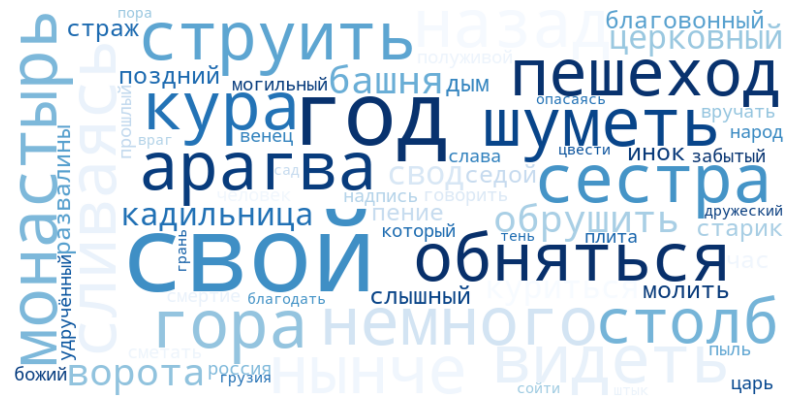

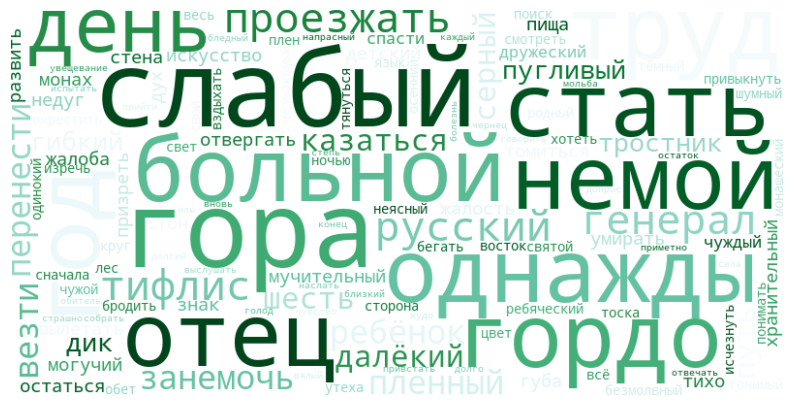

In [70]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color='white', colormap = 'Blues', width=800, height=400, random_state=21, max_font_size=110).generate(clean_texts[1])
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

wordcloud = WordCloud(background_color='white', colormap = 'BuGn', width=800, height=400, random_state=21, max_font_size=110).generate(clean_texts[2])
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


Итак, как я указывала ранее, первая глава является введением, из-за чего в ней преобладают слова, относящиеся к местности и времени. В ней мы узнаем, что действия разворачиваются в Грузии, которая на тот момент присоединилась к Российской Империи, на что указывает строчка: «Такой-то царь, в такой-то год, / Вручал России свой народ». 

Среди слов, относящихся к местности, довольно четко на графике-облаке выделяются «Кура», «Арагва», «гора», «монастырь», «башня». 

Во второй главе на облаке выделяются три прилагательных, относящихся в основном к главному герою. В частности: «слабый» и «больной» – так как именно таким его оставили в монастыре. 

Здесь же встречается слово «гордо», которое тоже относится к главному герою поэмы, ведь несмотря на недуги и все трудности, он сохранял в себе гордость. 

Также часто употребляется слово «гора». Это связано с тем, что действия разворачиваются в подобном ландшафте, а еще потому, что Мцыри сравнивается с «серной гор». 

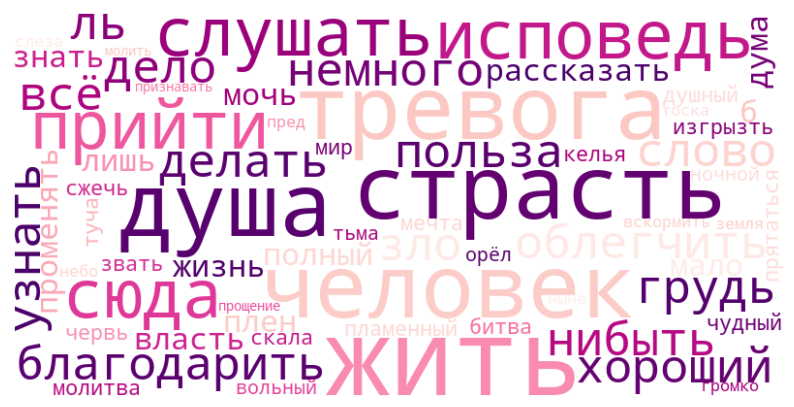

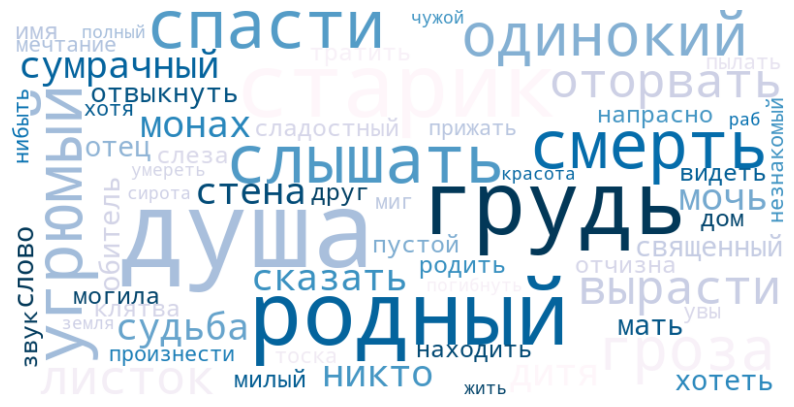

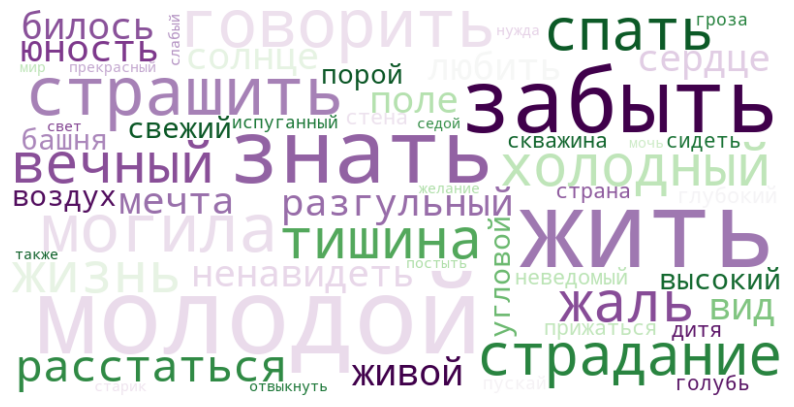

In [73]:
wordcloud = WordCloud(background_color='white', colormap = 'RdPu', width=800, height=400, random_state=21, max_font_size=110).generate(clean_texts[3])
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

wordcloud = WordCloud(background_color='white', colormap = 'PuBu_r', width=800, height=400, random_state=21, max_font_size=110).generate(clean_texts[4])
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

wordcloud = WordCloud(background_color='white', colormap = 'PRGn', width=800, height=400, random_state=21, max_font_size=110).generate(clean_texts[5])
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

*Задание 4. Вывод: В 100–200 словах опишите, как обработка раскрывает романтизм Лермонтова (контраст 'плена' и 'свободы').*

На самом деле, мне кажется, что двух глав не хватает для полноценного анализа текста. Когда берется хотя бы пять глав, то становится сильно проще отслеживать проявление романтизма, так как лучше раскрывается Мцыри (а я повторю, что он типичный романтический герой) и сюжет произведения в целом. 

Итак, какие проявления романтизма с помощью обработки текста я отметитла: 

1. **Действия происходят во вполне экзотических пейзажах**: среди гор и рек. Это отображается и на том же облаке слов, которое было построено в конце работы, и в таблице с топ-5 слов по первым 5 главам. Именно горы и Грузия, как мне кажется, становятся важнейшими образами в данной поэме. Без них образ Мцыри не получился бы таким наполненным и целостным. 
2. **В поэме культ чувств и эмоций, а не разума**. Эти эмоции, бушующие в главном герое, особенно четко проявляются с третьей главы — с начала его исповеди. Он признает — что также видно на облаке слов и по таблице, — что в нем много страсти и желания жить в мире тревог, а не в спокойном монастыре. Это, к слову, указывает на еще одно проявление ромнатизма, а именно: **двоемирие**. 

Вообще, та же вторая главая сочетает в себе (что опять-таки видно по полученным данным) болезненность и гордость героя, что уже указывает на его исключительность, а, например, в пятой главе, если обратиться к тому же облаку слов, видно, что сочетаются желание жить и молодость героя со страданиями, могилой и ненавситью. Чаще всего в тексте одна крайность сопровождает другую. 

---


#### **Шаг 10.** Декларация по использованию ИИ 

К сожалению, я пока в процессе принятия циклов, а также допускаю какие-то глупые ошибки в коде, поэтому честно признаюсь: ИИ использовала, чтобы понять, что не так с тем, что я пишу и иметь возможность устранить проблемы побыстрее, ну и иногда для исправления/улучшения каких-то циклов. В остальном старалась опираться на то, что мы делали на семинаре, так как все необходимое в целом есть в тетрадях. 